In [9]:
import pandas as pd
from wordcloud import WordCloud
from collections import Counter
import itertools
import numpy as np
import matplotlib.pyplot as plt

### csv to df

In [10]:
df = pd.read_csv("../data/02_lyrics_cleaned.csv")

In [11]:
df

,singer,lyrics,lyrics_nostop,lyrics_stemmed
0,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,denizlerde okyanuslarda dalgaların koynunda öm...,deniz okyanus dalga koyn ömür tükettik sonr su...
1,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,acıhda bağa vir biraz oğa vir çevir kazı yanma...,acıh bak vir biraz ok vir çevir kaz yanm aman ...
2,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,adem babayla havva anadan yana şeyler söylendi...,adem baba havv ana yan şey söylen sevda üzer s...
3,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,beni bırakıp gittiğinden beri terkedilmiş çocu...,ben bırakıp gittik ber terkedil çocuk çaresiz ...
4,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,ah tuti mucize guyem desem laf değil beli yari...,ah tuti muciz guyem dese laf değil bel yarim b...
...,...,...,...,...
4423,Şebnem Ferah,Aynıydı gökyüzümüz Savrulduk her birimiz İnsan...,aynıydı gökyüzümüz savrulduk birimiz i̇nsanlığ...,aynı gökyüz savrul bir i̇nsanlığa olt masum gö...
4424,Şebnem Ferah,Alnımdan akan ter Sana hiç değmedi Gözümden da...,alnımdan akan ter sana değmedi gözümden damlay...,aln akan ter san değm göz damlayan yaş deniz b...
4425,Şebnem Ferah,Hangi gün hangi an üzülsem ağlasam Halime güld...,hangi gün hangi an üzülsem ağlasam halime güld...,hangi gün hangi an üzül ağla halim gült yap et...
4426,Şebnem Ferah,Biriyle fena halde konuşmaya ihtiyacım var Bi...,biriyle fena halde konuşmaya ihtiyacım var bir...,biri fena halde konuşma ihtiyaç var biri fena ...


In [12]:
df["No"] = df.index

In [13]:
df = df.set_index("No")

### most frequent words

In [21]:
most_common_lyrics = Counter(" ".join(df["lyrics"]).split()).most_common(30)

In [22]:
most_common_lyrics

[('bir', 7554),
 ('bu', 3731),
 ('Bir', 3252),
 ('de', 2800),
 ('ne', 2671),
 ('beni', 2639),
 ('ben', 2532),
 ('gibi', 2312),
 ('var', 2107),
 ('sen', 2070),
 ('da', 1959),
 ('ki', 1759),
 ('bana', 1712),
 ('seni', 1709),
 ('her', 1700),
 ('yok', 1664),
 ('Bu', 1639),
 ('çok', 1576),
 ('Ben', 1573),
 ('ve', 1534),
 ('Ne', 1518),
 ('o', 1482),
 ('Sen', 1471),
 ('benim', 1335),
 ('mi', 1298),
 ('sana', 1163),
 ('gel', 1109),
 ('hep', 1056),
 ('gün', 1042),
 ('hiç', 1035)]

In [17]:
most_common_nostop = Counter(" ".join(df["lyrics_nostop"]).split()).most_common(30)

In [18]:
most_common_nostop

[('ben', 4131),
 ('sen', 3569),
 ('beni', 3391),
 ('seni', 2419),
 ('bana', 2293),
 ('var', 2253),
 ('yok', 1857),
 ('benim', 1727),
 ('gel', 1656),
 ('sana', 1651),
 ('gün', 1227),
 ('aşk', 1086),
 ('artık', 1081),
 ('kadar', 1067),
 ('senin', 1026),
 ('değil', 975),
 ('zaman', 967),
 ('ah', 959),
 ('olur', 917),
 ('olsun', 849),
 ('bak', 844),
 ('oldu', 839),
 ('tek', 821),
 ('dünya', 751),
 ('gece', 741),
 ('güzel', 736),
 ('şimdi', 715),
 ('son', 699),
 ('yar', 687),
 ('hayat', 682)]

In [19]:
most_common_stemmed = Counter(" ".join(df["lyrics_stemmed"]).split()).most_common(30)

In [20]:
most_common_stemmed

[('ben', 10454),
 ('sen', 8402),
 ('var', 3150),
 ('aşk', 2913),
 ('göz', 2462),
 ('ban', 2298),
 ('gün', 2279),
 ('yok', 2080),
 ('gel', 1999),
 ('yol', 1943),
 ('yer', 1701),
 ('san', 1682),
 ('kent', 1644),
 ('iç', 1469),
 ('değil', 1423),
 ('can', 1407),
 ('dünya', 1402),
 ('zaman', 1390),
 ('olt', 1388),
 ('son', 1363),
 ('yar', 1332),
 ('git', 1303),
 ('al', 1290),
 ('baş', 1278),
 ('yan', 1241),
 ('ar', 1241),
 ('olur', 1240),
 ('ols', 1236),
 ('dert', 1192),
 ('biz', 1106)]

In [23]:
freq = pd.Series(' '.join(df['lyrics_nostop']).split()).value_counts()[:50]


In [24]:
freq

ben       4131
sen       3569
beni      3391
seni      2419
bana      2293
var       2253
yok       1857
benim     1727
gel       1656
sana      1651
gün       1227
aşk       1086
artık     1081
kadar     1067
senin     1026
değil      975
zaman      967
ah         959
olur       917
olsun      849
bak        844
oldu       839
tek        821
dünya      751
gece       741
güzel      736
şimdi      715
son        699
yar        687
hayat      682
aman       627
bile       615
söyle      601
öyle       590
başka      580
senden     563
biraz      542
kaç        539
hadi       536
olmaz      525
gönül      512
al         508
benden     496
ver        479
zor        474
yeter      467
sonra      461
yalan      456
sensiz     448
the        448
dtype: int64

In [26]:
text = " ".join(review for review in df.lyrics_nostop)


#### Visualization(most_common)

In [27]:
from PIL import Image


In [36]:
music_mask = np.array(Image.open("music.png"))
music_mask

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

Maskenin beyaz kısmının 0 değil,255 olması gerekli(pixel intensity)
seçilen görselde zaten o şekilde, dönüşüme gerek yok

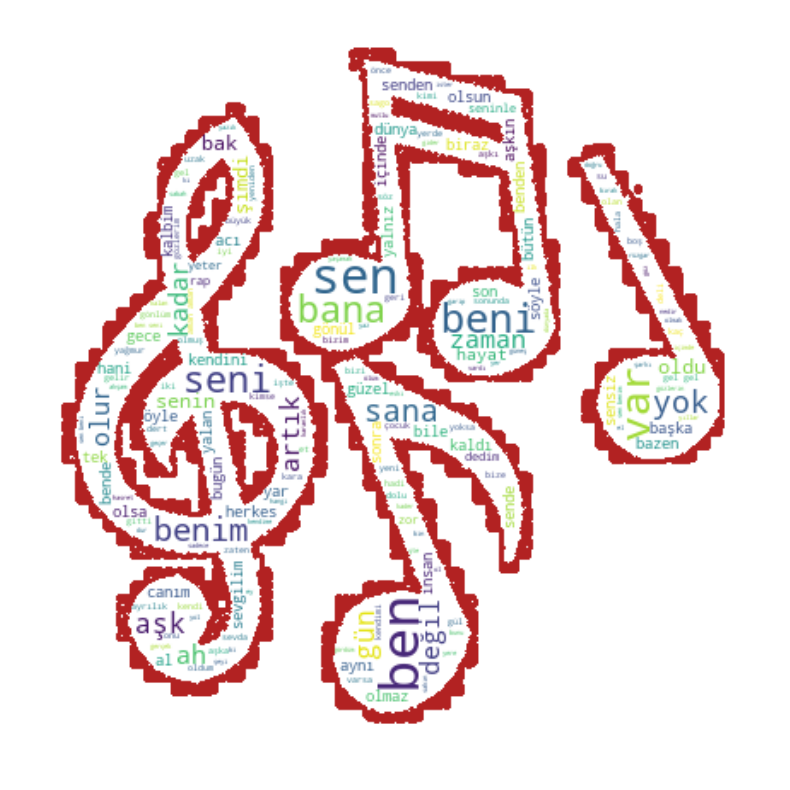

In [37]:
wc = WordCloud(background_color="white", max_words=1000, mask=music_mask,
                contour_width=3, contour_color='firebrick')

# Generate a wordcloud
wc.generate(text)

# store to file
wc.to_file("music.png")

# show
plt.figure(figsize=[20,10])
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

### unique words

In [38]:
df.lyrics_stemmed[250]

'güneş akşa batıp gün doğuyor çiçek solup solup tekrar açıyor der yara kapanıyor büyük acı unutuluyor korkulur hayat söyley ban ben aynı kala söyley ban elbet bazen çiçek açıp bazen solacak elbet dal dal konup sonr uçacak elbet bazen hızl dönüp bazen duracak elbet bazen söyleyip bazen susacak i̇nanmadım asl inanama şey son olduk elbet bugü ağlıyor yar gülecek elbet önç çekip gidip sonr dönecek'

In [39]:
df["unique_word"] = df.lyrics_stemmed.str.split().apply(set)


In [40]:
df.head()

,singer,lyrics,lyrics_nostop,lyrics_stemmed,unique_word
No,,,,,
0,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,denizlerde okyanuslarda dalgaların koynunda öm...,deniz okyanus dalga koyn ömür tükettik sonr su...,"{kaybolmak, el, dünya, karl, geri, boğulmak, s..."
1,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,acıhda bağa vir biraz oğa vir çevir kazı yanma...,acıh bak vir biraz ok vir çevir kaz yanm aman ...,"{man, çorp, omz, ayak, öyl, sonra, uyan, püskü..."
2,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,adem babayla havva anadan yana şeyler söylendi...,adem baba havv ana yan şey söylen sevda üzer s...,"{dünya, üzer, ol, gerek, gört, ferhat, gelir, ..."
3,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,beni bırakıp gittiğinden beri terkedilmiş çocu...,ben bırakıp gittik ber terkedil çocuk çaresiz ...,"{dönme, sor, verilecek, sorm, dönt, san, görme..."
4,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,ah tuti mucize guyem desem laf değil beli yari...,ah tuti muciz guyem dese laf değil bel yarim b...,"{olmayan, sine, laf, muciz, tuti, dil, saf, do..."


In [42]:
df.unique_word[250]

{'acı',
 'akşa',
 'asl',
 'aynı',
 'açıp',
 'açıyor',
 'ağlıyor',
 'ban',
 'batıp',
 'bazen',
 'ben',
 'bugü',
 'büyük',
 'dal',
 'der',
 'doğuyor',
 'duracak',
 'dönecek',
 'dönüp',
 'elbet',
 'gidip',
 'gülecek',
 'gün',
 'güneş',
 'hayat',
 'hızl',
 'inanama',
 'i̇nanmadım',
 'kala',
 'kapanıyor',
 'konup',
 'korkulur',
 'olduk',
 'solacak',
 'solup',
 'son',
 'sonr',
 'susacak',
 'söyley',
 'söyleyip',
 'tekrar',
 'unutuluyor',
 'uçacak',
 'yar',
 'yara',
 'çekip',
 'çiçek',
 'önç',
 'şey'}

In [43]:
len(df.unique_word[250])

49

df["TokenNO"] = df.Söz.str.split().apply(len)


df.TokenNO[251]

df.dtypes

In [47]:
unique_word_list = df.unique_word.tolist()

In [48]:
unique_no = []
for word in range(len(unique_word_list)):
    kelime_sayi = len(unique_word_list[word])
    unique_no.append(kelime_sayi)

In [49]:
unique_no[250]

49

In [50]:
df["unique_words_no"] = np.array(unique_no)

In [51]:
df.head()

,singer,lyrics,lyrics_nostop,lyrics_stemmed,unique_word,unique_words_no
No,,,,,,
0,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,denizlerde okyanuslarda dalgaların koynunda öm...,deniz okyanus dalga koyn ömür tükettik sonr su...,"{kaybolmak, el, dünya, karl, geri, boğulmak, s...",46
1,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,acıhda bağa vir biraz oğa vir çevir kazı yanma...,acıh bak vir biraz ok vir çevir kaz yanm aman ...,"{man, çorp, omz, ayak, öyl, sonra, uyan, püskü...",65
2,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,adem babayla havva anadan yana şeyler söylendi...,adem baba havv ana yan şey söylen sevda üzer s...,"{dünya, üzer, ol, gerek, gört, ferhat, gelir, ...",103
3,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,beni bırakıp gittiğinden beri terkedilmiş çocu...,ben bırakıp gittik ber terkedil çocuk çaresiz ...,"{dönme, sor, verilecek, sorm, dönt, san, görme...",42
4,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,ah tuti mucize guyem desem laf değil beli yari...,ah tuti muciz guyem dese laf değil bel yarim b...,"{olmayan, sine, laf, muciz, tuti, dil, saf, do...",21


#### Grouping singers by unique word count

In [57]:
gk = df.groupby('singer')['unique_words_no'].sum()

In [64]:
gk

singer
Barış Manço                 7621
Büyük Ev Ablukada           1189
Can Bonomo                  3147
Candan Erçetin              7611
Cem Adrian                  6773
Cem Karaca                  6780
Ceza                        9023
Duman                       3122
Ezhel                       3064
Feridun Düzağaç             4931
Kayahan                     4910
Mabel Matiz                 3579
Mazhar Fuat Özkan (MFÖ)     4213
Mor Ve Ötesi                3957
Mustafa Sandal              4882
Müslüm Gürses              16274
Nazan Öncel                 6141
Orhan Gencebay             14515
Pinhani                     2735
Sagopa Kajmer              56370
Serdar Ortaç               11113
Sertab Erener               7503
Sezen Aksu                 17419
Tarkan                      6630
Teoman                      4831
Yaşar                       4499
Yeni Türkü                  3729
Zeki Müren                 12989
Zülfü Livaneli              6072
Şebnem Ferah                4571
Nam

In [62]:
df.groupby(['singer']).mean()

,unique_words_no
singer,
Barış Manço,57.734848
Büyük Ev Ablukada,51.695652
Can Bonomo,52.450000
Candan Erçetin,55.554745
Cem Adrian,48.378571
Cem Karaca,49.852941
Ceza,196.152174
Duman,37.166667
Ezhel,133.217391


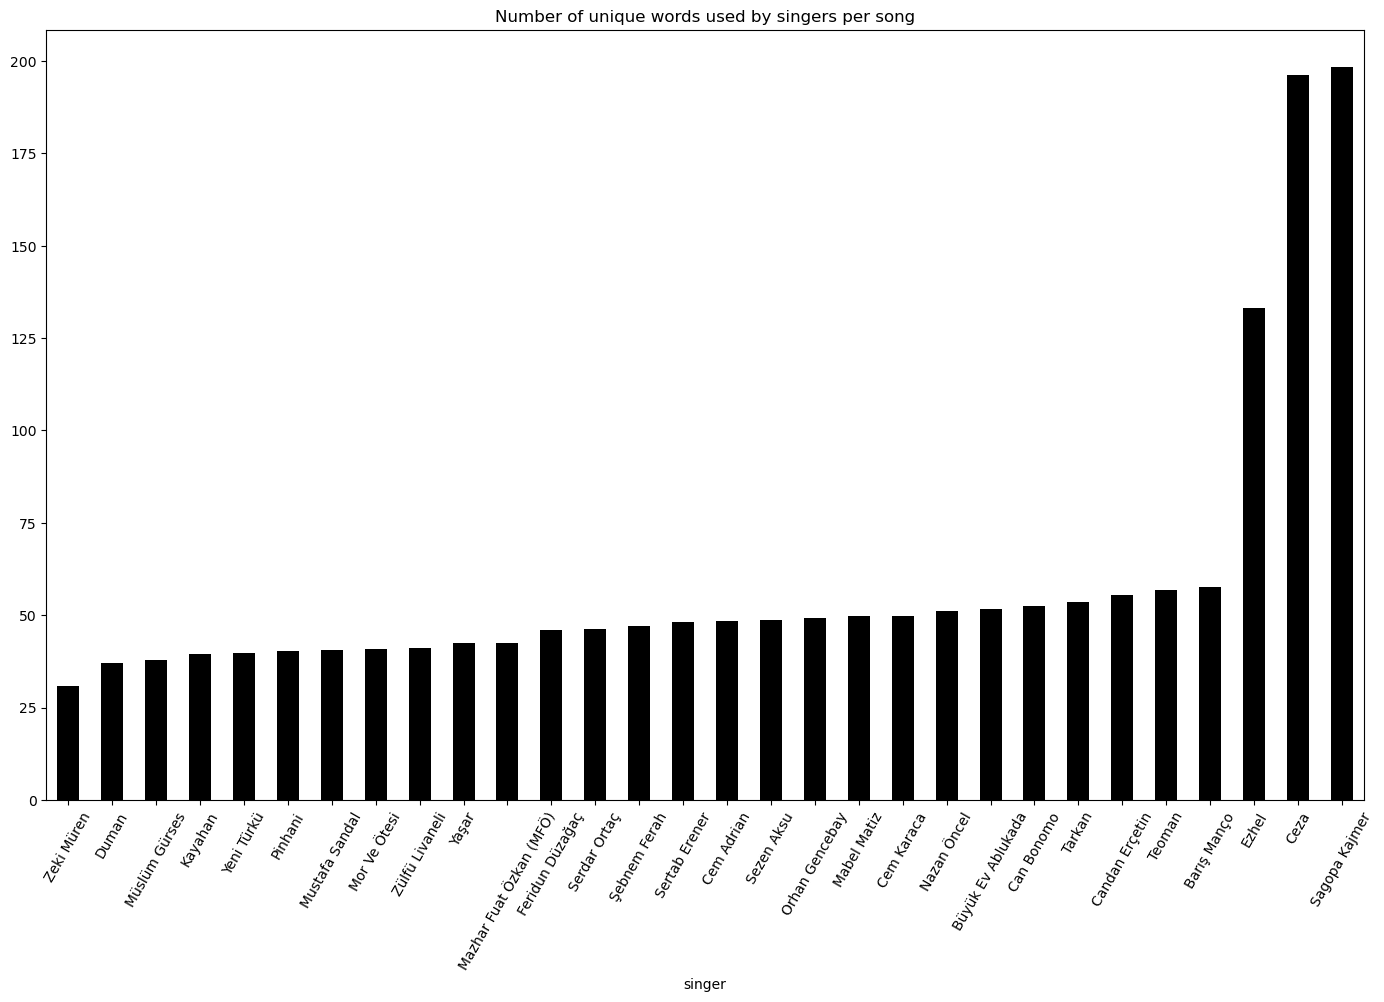

In [76]:
df.groupby("singer").mean().sort_values(by="unique_words_no").unique_words_no.plot.bar(color="black",title="Number of unique words used by singers per song",figsize=(17,10))
plt.xticks(rotation=60)
plt.show()

### Tokenization and Most Common Words

In [27]:
import nltk
from nltk.stem.porter import*

In [28]:
df["Token"] = df["Söz"].apply(nltk.word_tokenize)

In [29]:
df_bonomo = df[df.Şarkıcı == "Can Bonomo"]
df_sezen = df[df.Şarkıcı == "Sezen Aksu"]

In [30]:
temp = df_bonomo.Token
list_bono = list(itertools.chain(*temp.values))

In [31]:
list_bono[0]

'yolumu'

In [32]:
c = Counter(list_bono)
c.most_common(20)

[('var', 50),
 ('gel', 49),
 ('ah', 46),
 ('bak', 44),
 ('vah', 36),
 ('vay', 32),
 ('yaz', 30),
 ('başka', 30),
 ('zaman', 30),
 ('benim', 28),
 ('aman', 28),
 ('meczup', 24),
 ('güzel', 23),
 ('olur', 23),
 ('artık', 22),
 ('ölürüm', 22),
 ('gece', 20),
 ('kendini', 18),
 ('alev', 18),
 ('you', 18)]

In [33]:
print(c)

Counter({'var': 50, 'gel': 49, 'ah': 46, 'bak': 44, 'vah': 36, 'vay': 32, 'yaz': 30, 'başka': 30, 'zaman': 30, 'benim': 28, 'aman': 28, 'meczup': 24, 'güzel': 23, 'olur': 23, 'artık': 22, 'ölürüm': 22, 'gece': 20, 'kendini': 18, 'alev': 18, 'you': 18, 'dünya': 17, 'sevmek': 17, 'hih': 16, 'hah': 16, 'hi': 16, 'ali': 15, 'yollar': 15, 'bugün': 15, 'gün': 15, 'al': 15, 'durma': 15, 'baba': 14, 'senin': 14, 'vardı': 14, 'yan': 14, 'hadi': 13, 'kadar': 13, 'keyfim': 13, 'geri': 13, 'dur': 13, 'çocuk': 13, 'yol': 13, 'yalan': 12, 'olmaz': 12, 'gider': 12, 'be': 12, 'kız': 12, 'kimi': 12, 'ağlar': 12, 'me': 12, 'dayan': 12, 'yeniden': 11, 'kere': 11, 'deli': 11, 'affet': 11, 'gitme': 11, 'and': 11, 'alem': 10, 'ayıl': 10, 'yok': 10, 'kara': 10, 'ağla': 10, 'hani': 10, 'yağmurum': 10, 'sensiz': 10, 'gerek': 10, 'oldum': 10, 'zor': 10, 'ol': 10, 'onu': 10, 'der': 10, 'kal': 10, 'yeni': 10, 'baby': 10, 'hasret': 10, 'yürü': 9, 'aç': 9, 'tek': 9, 'canım': 9, 'biraz': 9, 'rakı': 9, 'sev': 9, 'geç

In [34]:
import matplotlib.pyplot as plt

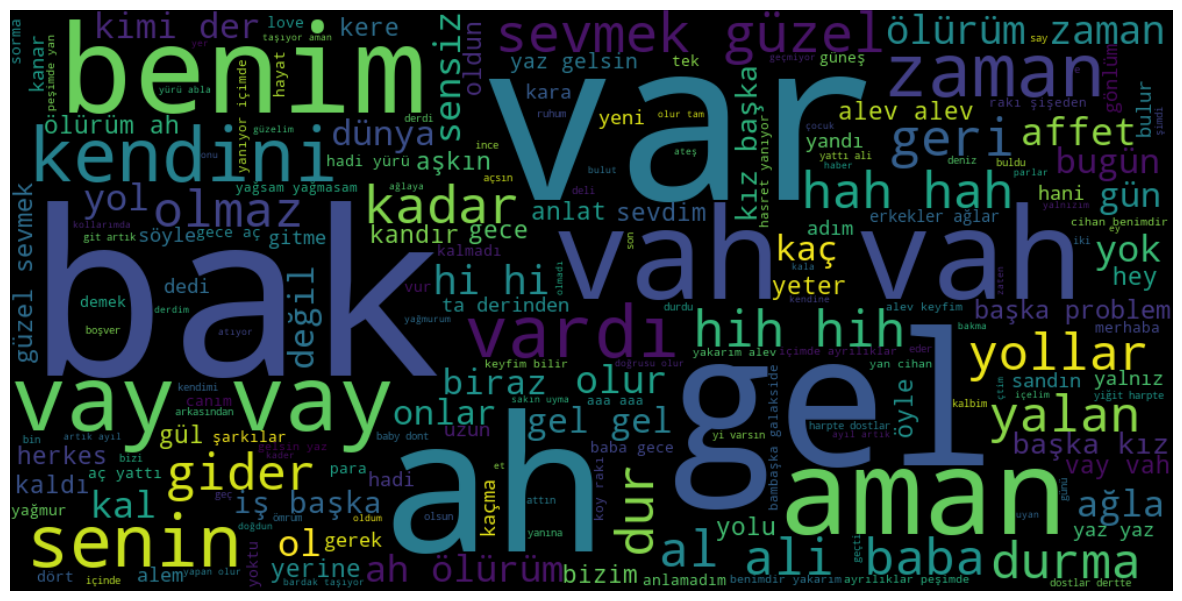

In [35]:
wordcloud = WordCloud(width=1000, height=500).generate((" ").join(list_bono))
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [36]:
temp = df_sezen.Token
list_sezen = list(itertools.chain(*temp.values))

In [37]:
c = Counter(list_sezen)
c.most_common(20)

[('gel', 225),
 ('yok', 150),
 ('var', 149),
 ('gün', 139),
 ('haydi', 135),
 ('ah', 125),
 ('artık', 125),
 ('zaman', 125),
 ('kadar', 118),
 ('oldu', 112),
 ('aşk', 101),
 ('benim', 99),
 ('değil', 98),
 ('dünya', 98),
 ('olur', 98),
 ('söyle', 92),
 ('şimdi', 85),
 ('biraz', 76),
 ('başka', 75),
 ('olsun', 74)]

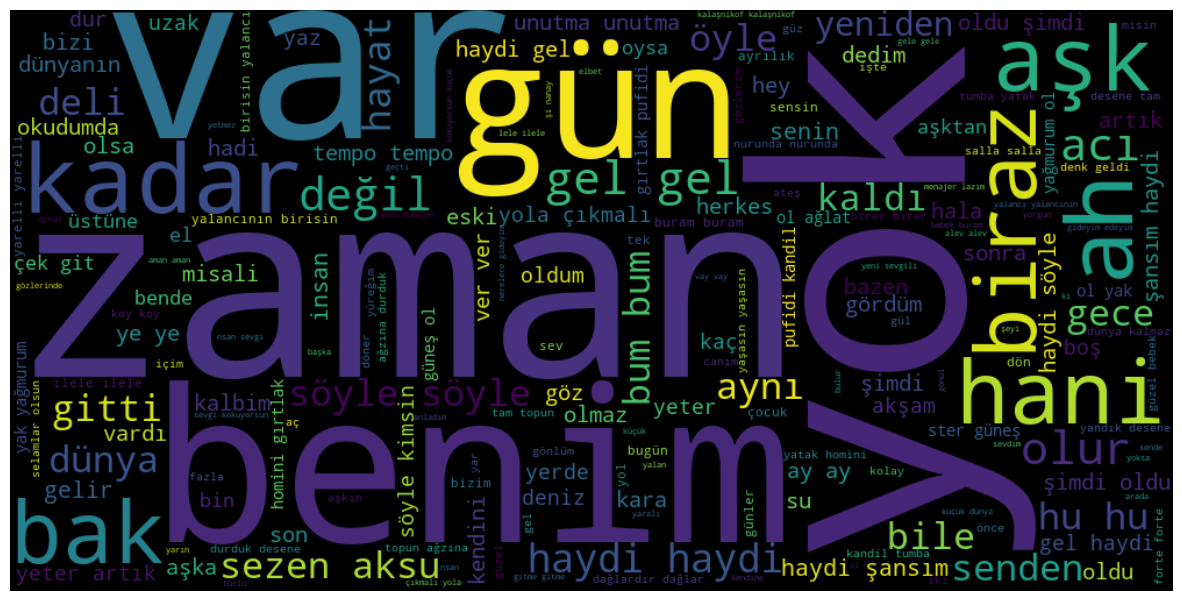

In [38]:
wordcloud = WordCloud(width=1000, height=500).generate((" ").join(list_sezen))
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [39]:
list_söz = df.Söz.tolist()

In [40]:
list_söz[133]

'aynı günün gecesi ilerliyor çilesi ruhumun bülbüleri hasta olmuş kısılmış sesleri yalan yanlış hevesleri seversin illetleri gözün dönünce bilmezsin napıp ettiğini ruhumun çileleri bitmiyor hileleri birgün hayır dediğine evet dedirtenleri bunlardan kaçmak lazım biraz dolanmak lazım başka kokular alıp dünya bakmak lazım'

In [ ]:
my_set = set((list[20]))
num_values = len(my_set)

print(num_values)